In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

ROOT = Path.cwd()
RESULTS = ROOT / 'results'
COLORS = {
    'heuristic': '#1f77b4',
    'consensus': '#d62728',
    'best_cache': '#2ca02c',
    'kalman_fixed': '#9467bd',
    'kalman_adaptive': '#8c564b',
}

In [4]:
benchmark_summary = pd.read_csv(RESULTS / 'oxford_pets_benchmark' / 'summary.csv')
benchmark_curves = pd.read_csv(RESULTS / 'oxford_pets_benchmark' / 'curves.csv')
ssm_summary = pd.read_csv(RESULTS / 'oxford_pets_ssm_only' / 'summary.csv')
ssm_curves = pd.read_csv(RESULTS / 'oxford_pets_ssm_only' / 'curves.csv')
hard_consensus_1000 = pd.read_csv(RESULTS / 'oxford_pets_consensus_batches' / 'L1000' / 'summary.csv')
hard_consensus_1000_curves = pd.read_csv(RESULTS / 'oxford_pets_consensus_batches' / 'L1000' / 'curves.csv')
soft_consensus_1000 = pd.read_csv(RESULTS / 'oxford_pets_soft_consensus' / 'summary.csv')
soft_consensus_1000_curves = pd.read_csv(RESULTS / 'oxford_pets_soft_consensus' / 'curves.csv')

consensus_500 = pd.DataFrame([
    {'config': 'views=8, topk=5, threshold=0.5', 'stream_length': 500, 'accuracy': 82.20, 'views': 8, 'top_k': 5, 'threshold': 0.5},
    {'config': 'views=8, topk=5, threshold=0.7', 'stream_length': 500, 'accuracy': 86.20, 'views': 8, 'top_k': 5, 'threshold': 0.7},
    {'config': 'views=8, topk=10, threshold=0.5', 'stream_length': 500, 'accuracy': 82.20, 'views': 8, 'top_k': 10, 'threshold': 0.5},
    {'config': 'views=8, topk=10, threshold=0.7', 'stream_length': 500, 'accuracy': 86.20, 'views': 8, 'top_k': 10, 'threshold': 0.7},
    {'config': 'views=16, topk=5, threshold=0.5', 'stream_length': 500, 'accuracy': 84.20, 'views': 16, 'top_k': 5, 'threshold': 0.5},
    {'config': 'views=16, topk=5, threshold=0.7', 'stream_length': 500, 'accuracy': 88.20, 'views': 16, 'top_k': 5, 'threshold': 0.7},
])

hard_log_text = (RESULTS / 'oxford_pets_consensus_batches' / 'L3669_consensus.log').read_text()
hard_matches = [float(x.rstrip('.')) for x in re.findall(r"TDA's test accuracy: ([0-9.]+)", hard_log_text)]
hard_consensus_3669 = pd.DataFrame({
    'step': [1000, 2000, 3000, 3669],
    'accuracy': [82.92, 83.76, 84.44, hard_matches[-1]],
    'method': 'Hard consensus',
})

soft_log_text = (RESULTS / 'oxford_pets_soft_consensus' / 'L3669_soft_consensus.log').read_text()
soft_matches = [float(x.rstrip('.')) for x in re.findall(r"TDA's test accuracy: ([0-9.]+)", soft_log_text)]
soft_consensus_3669 = pd.DataFrame({
    'step': [1000, 2000, 3000, 3669],
    'accuracy': [85.11, 85.61, 86.27, soft_matches[-1]],
    'method': 'Soft consensus',
})

heuristic_rows = ssm_summary[ssm_summary['method'] == 'tda_ssm_heuristic'].copy()
heuristic_from_1000 = soft_consensus_1000[soft_consensus_1000['method'] == 'tda_ssm_heuristic'][heuristic_rows.columns]
heuristic_rows = pd.concat([heuristic_rows, heuristic_from_1000], ignore_index=True)
heuristic_rows = heuristic_rows.drop_duplicates(subset=['stream_length'], keep='last').sort_values('stream_length')
heuristic_rows['method_clean'] = 'heuristic'

kalman_fixed_rows = ssm_summary[ssm_summary['method'] == 'tda_ssm_kalman-fixed'].copy()
kalman_fixed_rows['method_clean'] = 'kalman_fixed'
kalman_adaptive_rows = ssm_summary[ssm_summary['method'] == 'tda_ssm_kalman-adaptive'].copy()
kalman_adaptive_rows['method_clean'] = 'kalman_adaptive'

best_cache_rows = benchmark_summary.sort_values(['stream_length', 'accuracy']).groupby('stream_length', as_index=False).tail(1).copy()
best_cache_rows['method_clean'] = 'best_cache'

hard_1000_row = hard_consensus_1000[hard_consensus_1000['method'] == 'tda_ssm_heuristic_cv16_k5_t0.7'].iloc[0]
soft_1000_row = soft_consensus_1000[soft_consensus_1000['method'] == 'tda_ssm_heuristic_cv16_k5_t0.7'].iloc[0]

stream_accuracy = pd.DataFrame([
    {'stream_length': 500, 'method': 'Heuristic SSM', 'accuracy': float(heuristic_rows.loc[heuristic_rows['stream_length'] == 500, 'accuracy'].iloc[0])},
    {'stream_length': 1000, 'method': 'Heuristic SSM', 'accuracy': float(heuristic_rows.loc[heuristic_rows['stream_length'] == 1000, 'accuracy'].iloc[0])},
    {'stream_length': 2000, 'method': 'Heuristic SSM', 'accuracy': float(heuristic_rows.loc[heuristic_rows['stream_length'] == 2000, 'accuracy'].iloc[0])},
    {'stream_length': 3669, 'method': 'Heuristic SSM', 'accuracy': float(heuristic_rows.loc[heuristic_rows['stream_length'] == 3669, 'accuracy'].iloc[0])},
    {'stream_length': 500, 'method': 'Hard consensus', 'accuracy': 88.20},
    {'stream_length': 1000, 'method': 'Hard consensus', 'accuracy': float(hard_1000_row['accuracy'])},
    {'stream_length': 3669, 'method': 'Hard consensus', 'accuracy': float(hard_consensus_3669.loc[hard_consensus_3669['step'] == 3669, 'accuracy'].iloc[0])},
    {'stream_length': 1000, 'method': 'Soft consensus', 'accuracy': float(soft_1000_row['accuracy'])},
    {'stream_length': 3669, 'method': 'Soft consensus', 'accuracy': float(soft_consensus_3669.loc[soft_consensus_3669['step'] == 3669, 'accuracy'].iloc[0])},
])

print('Loaded experiment sources successfully.')
print(f"Hard consensus final 3669 accuracy: {hard_consensus_3669.loc[hard_consensus_3669['step'] == 3669, 'accuracy'].iloc[0]:.2f}%")
print(f"Soft consensus final 3669 accuracy: {soft_consensus_3669.loc[soft_consensus_3669['step'] == 3669, 'accuracy'].iloc[0]:.2f}%")

Loaded experiment sources successfully.
Hard consensus final 3669 accuracy: 84.41%
Soft consensus final 3669 accuracy: 86.10%


In [5]:
summary_table = heuristic_rows[['stream_length', 'accuracy', 'final_forgetting', 'mean_forgetting', 'avg_step_time_ms', 'peak_device_memory_mb']].copy()
summary_table = summary_table.rename(columns={
    'accuracy': 'heuristic_accuracy',
    'final_forgetting': 'heuristic_final_forgetting',
    'mean_forgetting': 'heuristic_mean_forgetting',
    'avg_step_time_ms': 'heuristic_step_ms',
    'peak_device_memory_mb': 'heuristic_peak_mem_mb',
})

consensus_snapshot = pd.DataFrame([
    {
        'stream_length': 500,
        'hard_consensus_accuracy': 88.20,
        'soft_consensus_accuracy': np.nan,
        'hard_step_ms': np.nan,
        'soft_step_ms': np.nan,
    },
    {
        'stream_length': 1000,
        'hard_consensus_accuracy': float(hard_1000_row['accuracy']),
        'soft_consensus_accuracy': float(soft_1000_row['accuracy']),
        'hard_step_ms': float(hard_1000_row['avg_step_time_ms']),
        'soft_step_ms': float(soft_1000_row['avg_step_time_ms']),
    },
    {
        'stream_length': 3669,
        'hard_consensus_accuracy': float(hard_consensus_3669.loc[hard_consensus_3669['step'] == 3669, 'accuracy'].iloc[0]),
        'soft_consensus_accuracy': float(soft_consensus_3669.loc[soft_consensus_3669['step'] == 3669, 'accuracy'].iloc[0]),
        'hard_step_ms': np.nan,
        'soft_step_ms': np.nan,
    },
])

best_cache_snapshot = best_cache_rows[['stream_length', 'method', 'accuracy', 'mean_forgetting', 'avg_step_time_ms', 'peak_device_memory_mb']].copy()
best_cache_snapshot = best_cache_snapshot.rename(columns={
    'method': 'best_cache_method',
    'accuracy': 'best_cache_accuracy',
    'mean_forgetting': 'best_cache_mean_forgetting',
    'avg_step_time_ms': 'best_cache_step_ms',
    'peak_device_memory_mb': 'best_cache_peak_mem_mb',
})

comparison_table = summary_table.merge(consensus_snapshot, on='stream_length', how='outer').merge(best_cache_snapshot, on='stream_length', how='left').sort_values('stream_length')
comparison_table['hard_minus_heuristic'] = comparison_table['hard_consensus_accuracy'] - comparison_table['heuristic_accuracy']
comparison_table['soft_minus_heuristic'] = comparison_table['soft_consensus_accuracy'] - comparison_table['heuristic_accuracy']
comparison_table['hard_minus_best_cache'] = comparison_table['hard_consensus_accuracy'] - comparison_table['best_cache_accuracy']
comparison_table['soft_minus_best_cache'] = comparison_table['soft_consensus_accuracy'] - comparison_table['best_cache_accuracy']

display(comparison_table.round(3))

,stream_length,heuristic_accuracy,heuristic_final_forgetting,heuristic_mean_forgetting,heuristic_step_ms,heuristic_peak_mem_mb,hard_consensus_accuracy,soft_consensus_accuracy,hard_step_ms,soft_step_ms,best_cache_method,best_cache_accuracy,best_cache_mean_forgetting,best_cache_step_ms,best_cache_peak_mem_mb,hard_minus_heuristic,soft_minus_heuristic,hard_minus_best_cache,soft_minus_best_cache
0,500,85.400,14.600,18.468,23.706,415.173,88.20,NaN,NaN,NaN,tda_cache_k20,91.2,7.578,21.417,611.322,2.800,NaN,-3.0,NaN
1,1000,78.600,21.400,18.750,22.688,415.173,79.20,78.9,143.894,139.813,tda_cache_k20,81.7,11.130,22.602,826.867,0.600,0.300,-2.5,-2.8
2,2000,84.600,15.400,18.512,22.664,415.173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3669,85.963,14.037,17.003,22.502,415.173,84.41,86.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.553,0.137,NaN,NaN


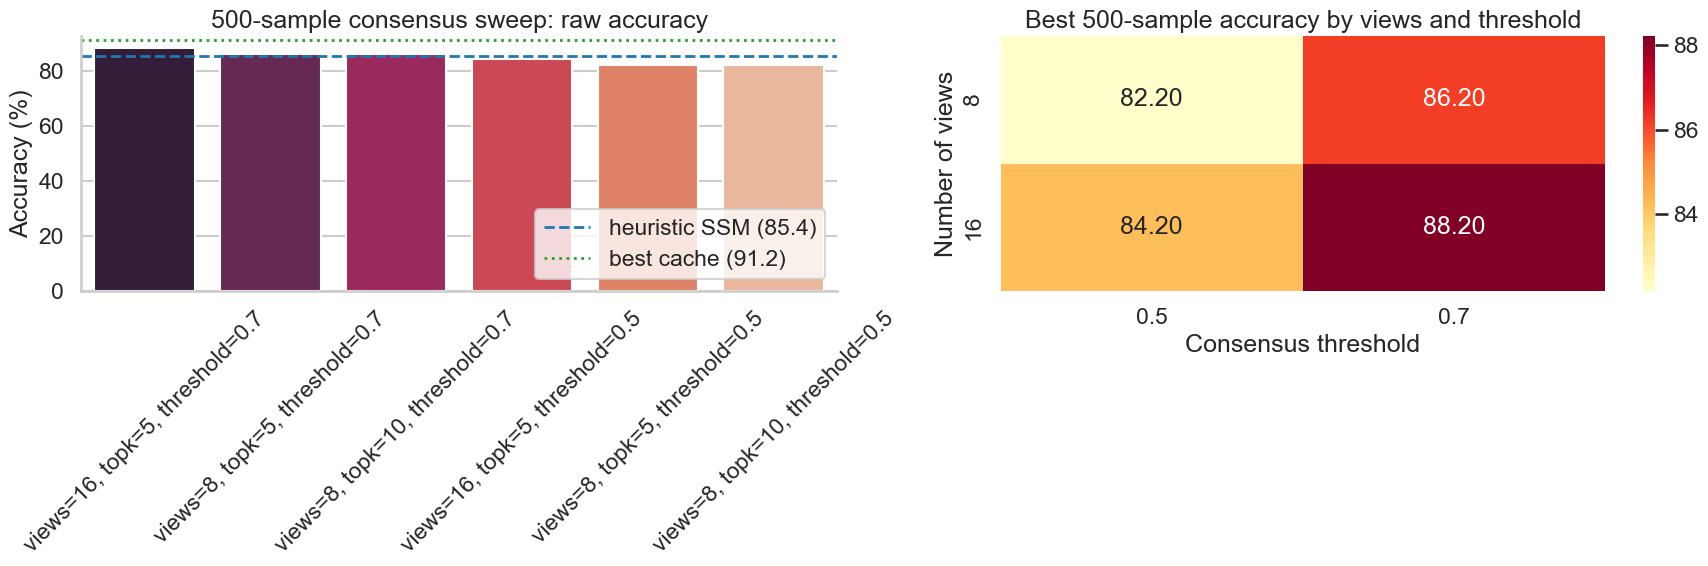

In [14]:
heuristic_500 = float(heuristic_rows.loc[heuristic_rows['stream_length'] == 500, 'accuracy'].iloc[0])
best_cache_500 = float(best_cache_rows.loc[best_cache_rows['stream_length'] == 500, 'accuracy'].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ordered = consensus_500.sort_values('accuracy', ascending=False)
sns.barplot(data=ordered, x='config', y='accuracy', hue='config', dodge=False, legend=False, ax=axes[0], palette='rocket')
axes[0].axhline(heuristic_500, color=COLORS['heuristic'], linestyle='--', linewidth=2, label=f'heuristic SSM ({heuristic_500:.1f})')
axes[0].axhline(best_cache_500, color=COLORS['best_cache'], linestyle=':', linewidth=2, label=f'best cache ({best_cache_500:.1f})')
axes[0].set_title('500-sample consensus sweep: raw accuracy')
axes[0].set_xlabel('')
axes[0].set_ylabel('Accuracy (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='lower right')

heatmap_df = consensus_500.pivot_table(index='views', columns='threshold', values='accuracy', aggfunc='max')
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Best 500-sample accuracy by views and threshold')
axes[1].set_xlabel('Consensus threshold')
axes[1].set_ylabel('Number of views')

plt.tight_layout()
plt.show()

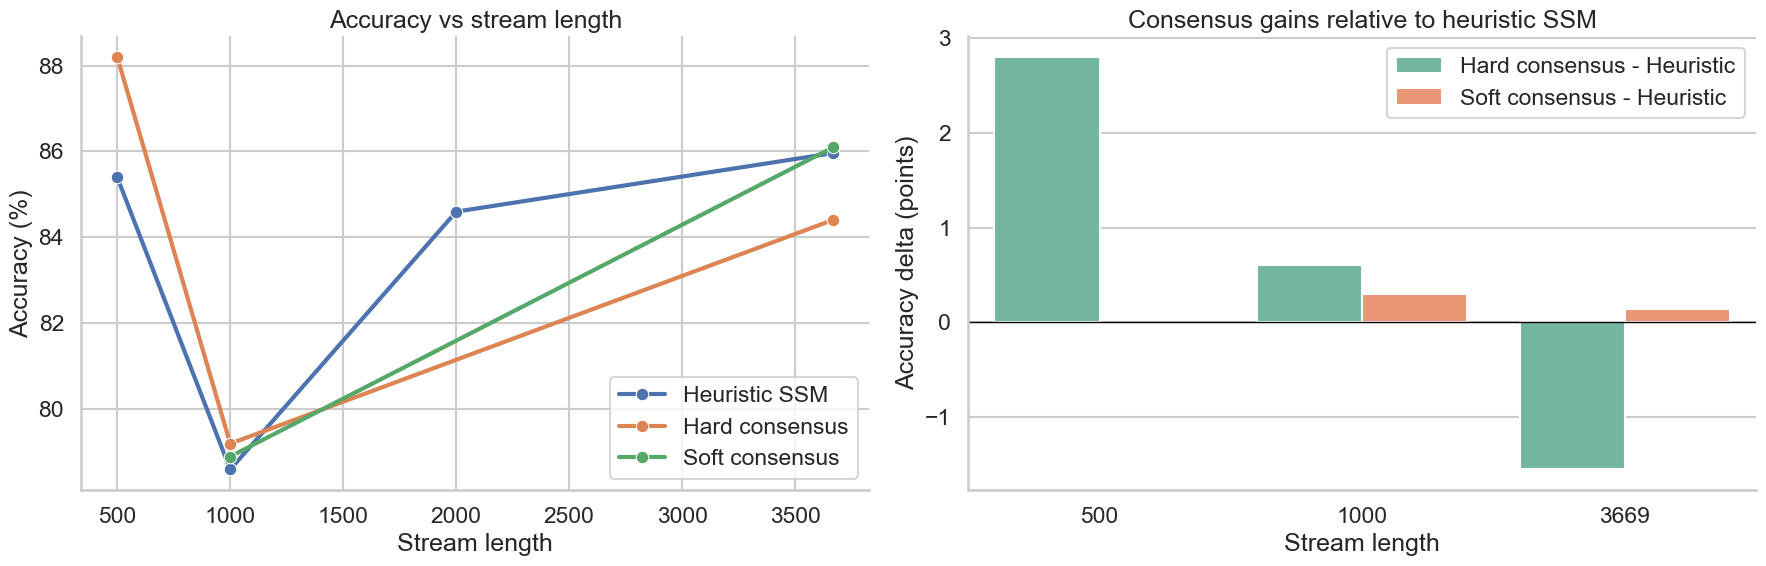

In [6]:
accuracy_plot_df = stream_accuracy.copy()

gain_df = comparison_table[['stream_length', 'hard_minus_heuristic', 'soft_minus_heuristic']].copy()
gain_long = gain_df.melt('stream_length', var_name='comparison', value_name='accuracy_delta').dropna()
gain_long['comparison'] = gain_long['comparison'].map({
    'hard_minus_heuristic': 'Hard consensus - Heuristic',
    'soft_minus_heuristic': 'Soft consensus - Heuristic',
})

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.lineplot(data=accuracy_plot_df, x='stream_length', y='accuracy', hue='method', marker='o', linewidth=3, ax=axes[0])
axes[0].set_title('Accuracy vs stream length')
axes[0].set_xlabel('Stream length')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(title='')

sns.barplot(data=gain_long, x='stream_length', y='accuracy_delta', hue='comparison', ax=axes[1], palette='Set2')
axes[1].axhline(0.0, color='black', linewidth=1)
axes[1].set_title('Consensus gains relative to heuristic SSM')
axes[1].set_xlabel('Stream length')
axes[1].set_ylabel('Accuracy delta (points)')
axes[1].legend(title='')

plt.tight_layout()
plt.show()

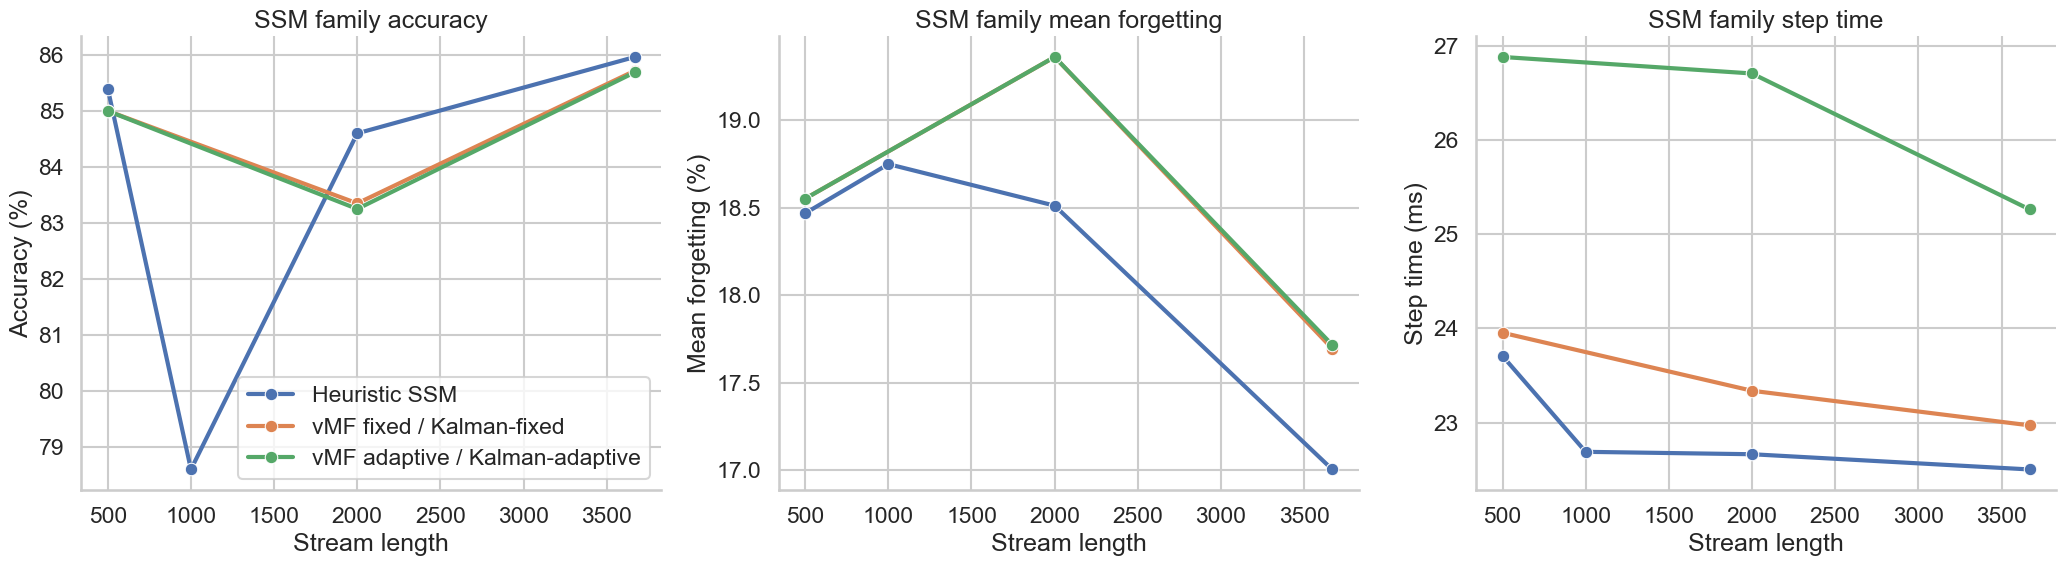

In [9]:
method_summary = pd.concat([
    heuristic_rows.assign(method_label='Heuristic SSM'),
    kalman_fixed_rows.assign(method_label='vMF fixed / Kalman-fixed'),
    kalman_adaptive_rows.assign(method_label='vMF adaptive / Kalman-adaptive'),
])[['stream_length', 'method_label', 'accuracy', 'mean_forgetting', 'avg_step_time_ms']]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
sns.lineplot(data=method_summary, x='stream_length', y='accuracy', hue='method_label', marker='o', linewidth=3, ax=axes[0])
axes[0].set_title('SSM family accuracy')
axes[0].set_xlabel('Stream length')
axes[0].set_ylabel('Accuracy (%)')

sns.lineplot(data=method_summary, x='stream_length', y='mean_forgetting', hue='method_label', marker='o', linewidth=3, ax=axes[1])
axes[1].set_title('SSM family mean forgetting')
axes[1].set_xlabel('Stream length')
axes[1].set_ylabel('Mean forgetting (%)')

sns.lineplot(data=method_summary, x='stream_length', y='avg_step_time_ms', hue='method_label', marker='o', linewidth=3, ax=axes[2])
axes[2].set_title('SSM family step time')
axes[2].set_xlabel('Stream length')
axes[2].set_ylabel('Step time (ms)')

for ax in axes[1:]:
    ax.legend_.remove()
axes[0].legend(title='')
plt.tight_layout()
plt.show()

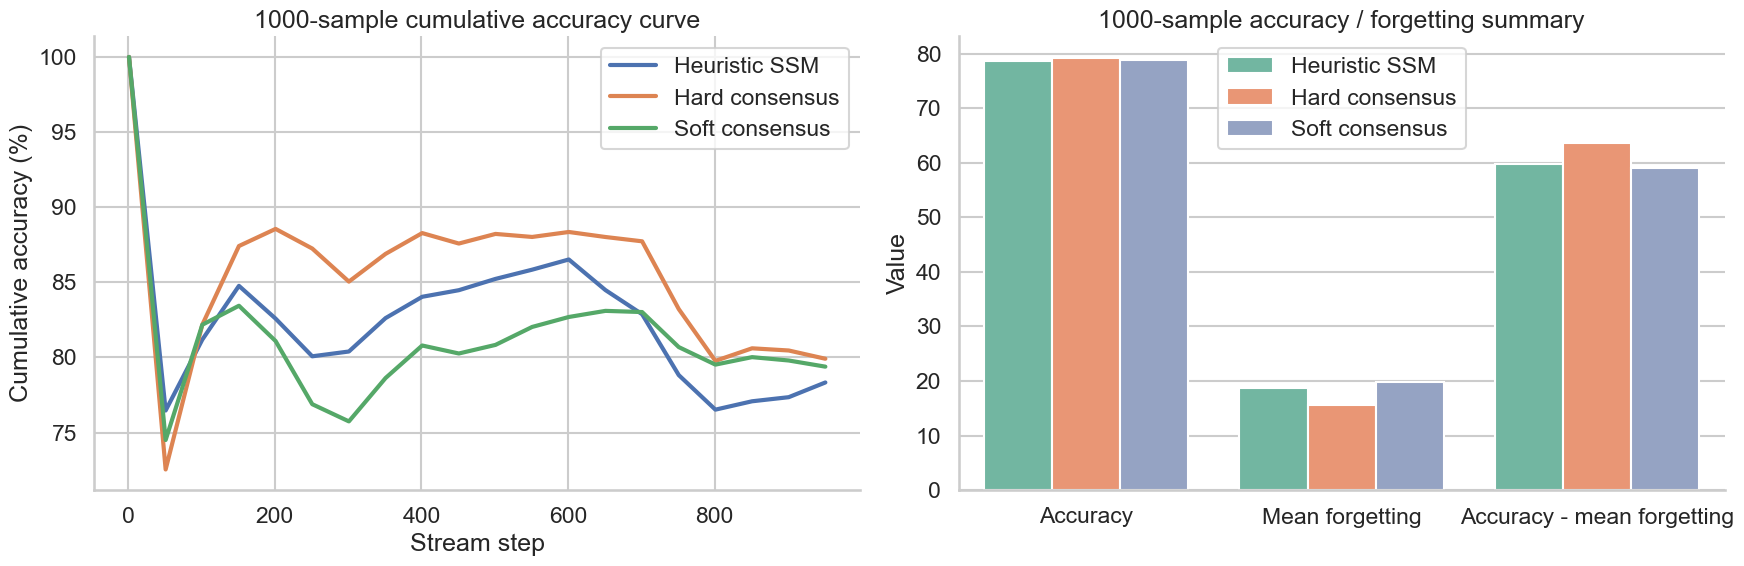

In [7]:
curve_1000 = pd.concat([
    soft_consensus_1000_curves[soft_consensus_1000_curves['method'] == 'tda_ssm_heuristic'].assign(method_label='Heuristic SSM'),
    hard_consensus_1000_curves[hard_consensus_1000_curves['method'] == 'tda_ssm_heuristic_cv16_k5_t0.7'].assign(method_label='Hard consensus'),
    soft_consensus_1000_curves[soft_consensus_1000_curves['method'] == 'tda_ssm_heuristic_cv16_k5_t0.7'].assign(method_label='Soft consensus'),
]).copy()

stability_1000 = pd.DataFrame([
    {
        'method_label': 'Heuristic SSM',
        'accuracy': float(heuristic_rows.loc[heuristic_rows['stream_length'] == 1000, 'accuracy'].iloc[0]),
        'mean_forgetting': float(heuristic_rows.loc[heuristic_rows['stream_length'] == 1000, 'mean_forgetting'].iloc[0]),
    },
    {
        'method_label': 'Hard consensus',
        'accuracy': float(hard_1000_row['accuracy']),
        'mean_forgetting': float(hard_1000_row['mean_forgetting']),
    },
    {
        'method_label': 'Soft consensus',
        'accuracy': float(soft_1000_row['accuracy']),
        'mean_forgetting': float(soft_1000_row['mean_forgetting']),
    },
])
stability_1000['stability_adjusted_accuracy'] = stability_1000['accuracy'] - stability_1000['mean_forgetting']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.lineplot(data=curve_1000, x='step', y='cumulative_accuracy', hue='method_label', linewidth=3, ax=axes[0])
axes[0].set_title('1000-sample cumulative accuracy curve')
axes[0].set_xlabel('Stream step')
axes[0].set_ylabel('Cumulative accuracy (%)')
axes[0].legend(title='')

metric_long = stability_1000.melt(id_vars='method_label', value_vars=['accuracy', 'mean_forgetting', 'stability_adjusted_accuracy'], var_name='metric', value_name='value')
metric_long['metric'] = metric_long['metric'].map({
    'accuracy': 'Accuracy',
    'mean_forgetting': 'Mean forgetting',
    'stability_adjusted_accuracy': 'Accuracy - mean forgetting',
})
sns.barplot(data=metric_long, x='metric', y='value', hue='method_label', ax=axes[1], palette='Set2')
axes[1].set_title('1000-sample accuracy / forgetting summary')
axes[1].set_xlabel('')
axes[1].set_ylabel('Value')
axes[1].legend(title='')

plt.tight_layout()
plt.show()

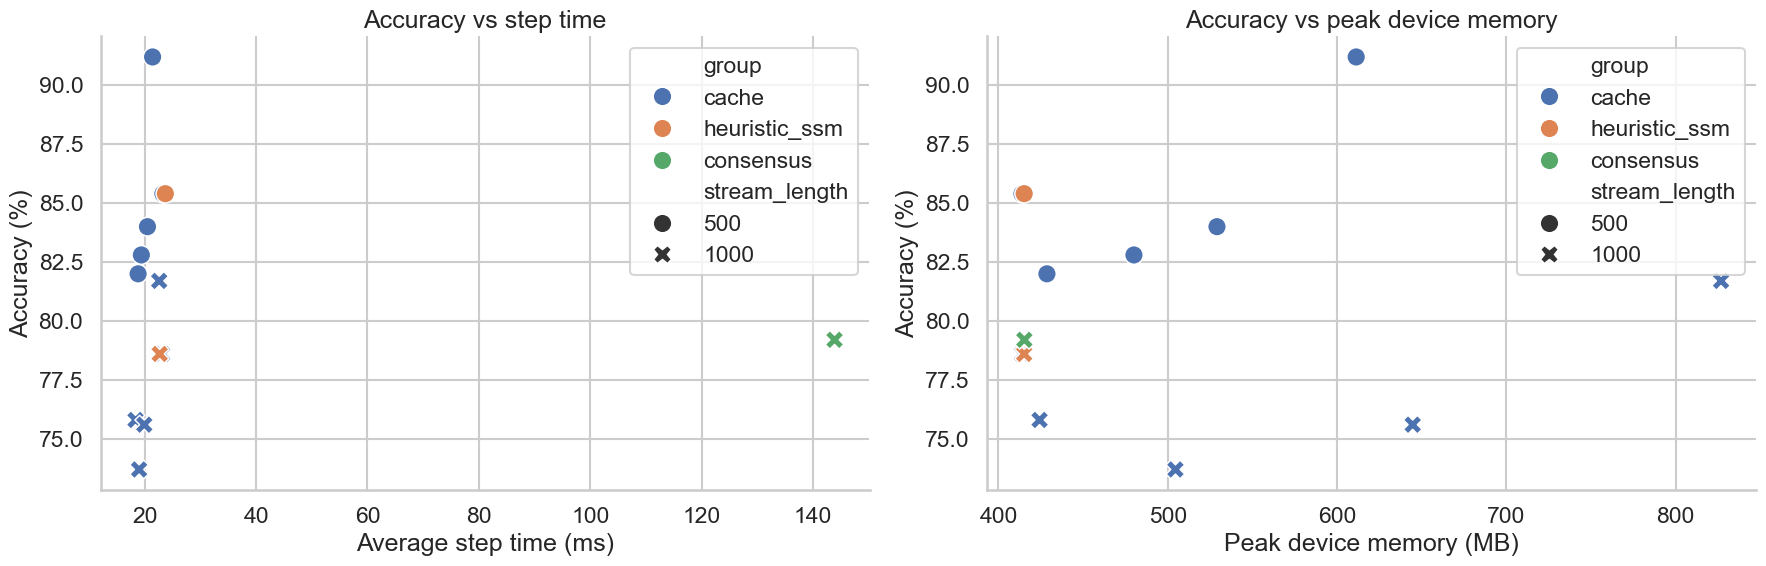

In [11]:
efficiency_df = pd.concat([
    benchmark_summary[benchmark_summary['stream_length'].isin([500, 1000])][['method', 'stream_length', 'accuracy', 'avg_step_time_ms', 'peak_device_memory_mb']].assign(group='cache'),
    heuristic_rows[heuristic_rows['stream_length'].isin([500, 1000])][['method', 'stream_length', 'accuracy', 'avg_step_time_ms', 'peak_device_memory_mb']].assign(group='heuristic_ssm'),
    consensus_1000_summary[consensus_1000_summary['method'] == 'tda_ssm_heuristic_cv16_k5_t0.7'][['method', 'stream_length', 'accuracy', 'avg_step_time_ms', 'peak_device_memory_mb']].assign(group='consensus'),
]).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.scatterplot(data=efficiency_df, x='avg_step_time_ms', y='accuracy', hue='group', style='stream_length', s=180, ax=axes[0])
axes[0].set_title('Accuracy vs step time')
axes[0].set_xlabel('Average step time (ms)')
axes[0].set_ylabel('Accuracy (%)')

sns.scatterplot(data=efficiency_df, x='peak_device_memory_mb', y='accuracy', hue='group', style='stream_length', s=180, ax=axes[1])
axes[1].set_title('Accuracy vs peak device memory')
axes[1].set_xlabel('Peak device memory (MB)')
axes[1].set_ylabel('Accuracy (%)')

for ax in axes:
    ax.legend(title='')

plt.tight_layout()
plt.show()

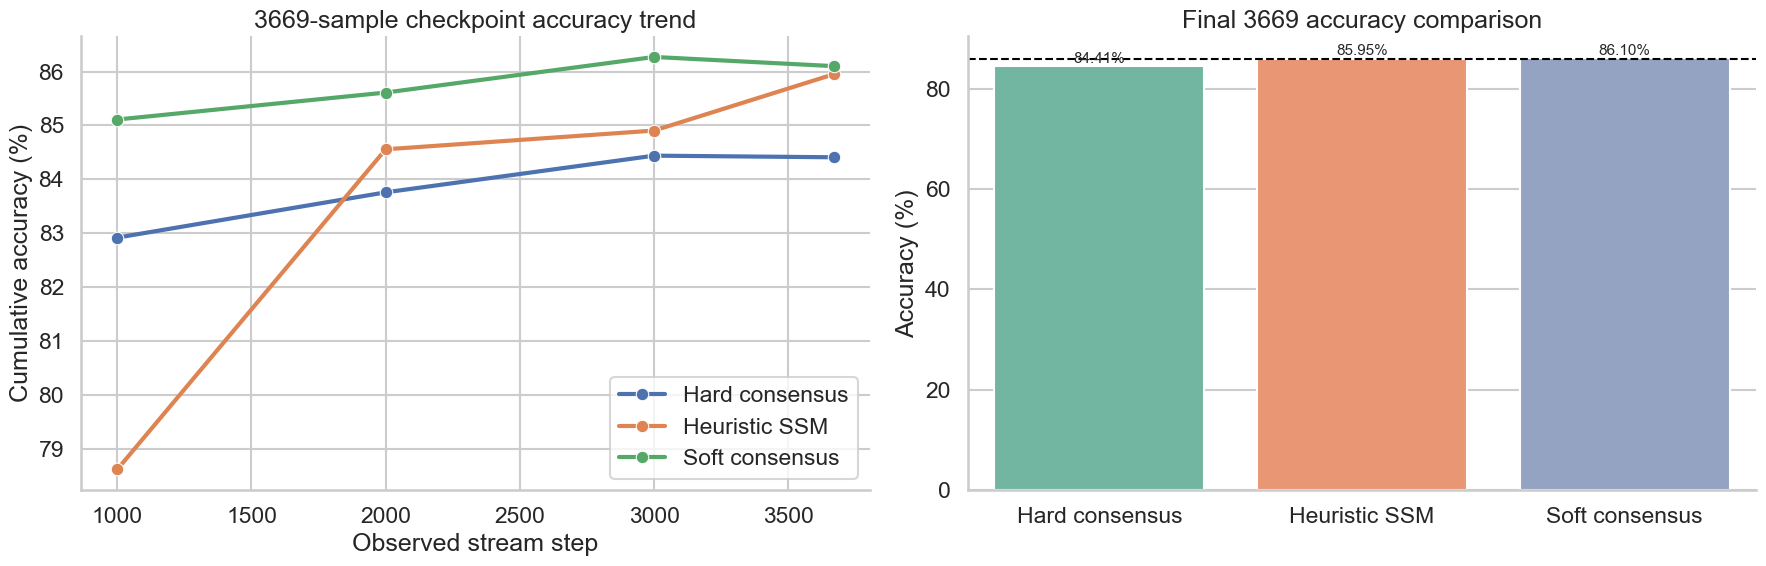

In [8]:
heuristic_curve_3669 = ssm_curves[(ssm_curves['method'] == 'tda_ssm_heuristic') & (ssm_curves['stream_length'] == 3669)].copy()
checkpoint_steps = [1000, 2000, 3000, 3669]

nearest_rows = []
for step in checkpoint_steps:
    idx = (heuristic_curve_3669['step'] - step).abs().idxmin()
    row = heuristic_curve_3669.loc[idx]
    nearest_rows.append({'step': step, 'accuracy': row['cumulative_accuracy'], 'method': 'Heuristic SSM'})

heuristic_3669_checkpoints = pd.DataFrame(nearest_rows)
long_stream_compare = pd.concat([
    heuristic_3669_checkpoints,
    hard_consensus_3669[['step', 'accuracy', 'method']],
    soft_consensus_3669[['step', 'accuracy', 'method']],
]).sort_values(['method', 'step'])

final_bar = long_stream_compare[long_stream_compare['step'] == 3669].copy()
final_bar['delta_vs_heuristic'] = final_bar['accuracy'] - float(heuristic_rows.loc[heuristic_rows['stream_length'] == 3669, 'accuracy'].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.lineplot(data=long_stream_compare, x='step', y='accuracy', hue='method', marker='o', linewidth=3, ax=axes[0])
axes[0].set_title('3669-sample checkpoint accuracy trend')
axes[0].set_xlabel('Observed stream step')
axes[0].set_ylabel('Cumulative accuracy (%)')
axes[0].legend(title='')

sns.barplot(data=final_bar, x='method', y='accuracy', hue='method', dodge=False, legend=False, ax=axes[1], palette='Set2')
axes[1].axhline(float(heuristic_rows.loc[heuristic_rows['stream_length'] == 3669, 'accuracy'].iloc[0]), color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Final 3669 accuracy comparison')
axes[1].set_xlabel('')
axes[1].set_ylabel('Accuracy (%)')
for idx, row in final_bar.reset_index(drop=True).iterrows():
    axes[1].text(idx, row['accuracy'] + 0.08, f"{row['accuracy']:.2f}%", ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [9]:
takeaways = pd.DataFrame([
    {
        'question': 'What mattered most in the 500 sweep?',
        'answer': 'A stricter threshold (0.7) mattered more than widening top-k. The best hard-consensus short-stream setting was 16 views, top-k 5, threshold 0.7.',
    },
    {
        'question': 'Did hard consensus solve the long-stream problem?',
        'answer': 'No. It won at 500, was only slightly competitive at 1000, and dropped to 84.41% at 3669, clearly below heuristic SSM at 85.96%.',
    },
    {
        'question': 'Did soft consensus improve the 3669 result?',
        'answer': 'Yes, but modestly. Soft consensus reached 86.10% at 3669, recovering the hard-consensus loss and finishing about +0.14 points above heuristic SSM.',
    },
    {
        'question': 'What is the main cost?',
        'answer': 'Compute. Soft consensus needs many extra CLIP forward passes. The 3669 run took about 10m45s, versus about 2m12s for heuristic SSM.',
    },
    {
        'question': 'What is the real conclusion for the mentor?',
        'answer': 'Using distribution agreement instead of hard argmax consensus fixes the long-stream regression, but the gain is still small. The method is now credible, not decisive.',
    },
])

display(takeaways)

,question,answer
0,What mattered most in the 500 sweep?,A stricter threshold (0.7) mattered more than ...
1,Did hard consensus solve the long-stream problem?,"No. It won at 500, was only slightly competiti..."
2,Did soft consensus improve the 3669 result?,"Yes, but modestly. Soft consensus reached 86.1..."
3,What is the main cost?,Compute. Soft consensus needs many extra CLIP ...
4,What is the real conclusion for the mentor?,Using distribution agreement instead of hard a...
